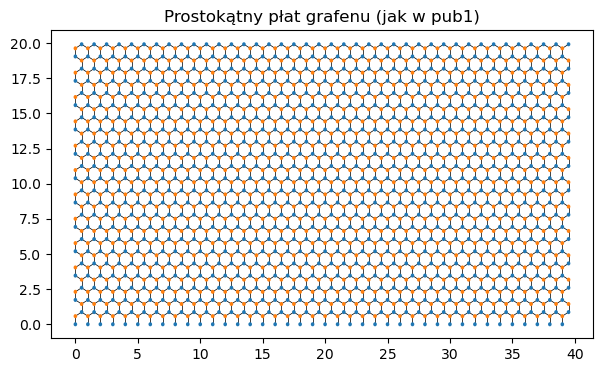

In [18]:
import kwant
import numpy as np
import matplotlib.pyplot as plt

# 1. Definicje
sigma_z = np.array([[1, 0], [0, -1]])
lat = kwant.lattice.honeycomb(norbs=2)
a, b = lat.sublattices
sys = kwant.Builder()

# 2. Definicja prostokąta (współrzędne x i y w jednostkach stałej sieci)
# To jest "wycinarka", która sprawi, że system nie będzie pochylony
def rectangle(pos):
    x, y = pos
    return 0 <= x < 40 and 0 <= y < 20

# 3. Wypełnianie prostokąta atomami
# lat.shape wybiera tylko te atomy, które mieszczą się w funkcji 'rectangle'
sys[lat.shape(rectangle, (0, 0))] = 0.1 * sigma_z

# 4. Przeskoki
sys[lat.neighbors()] = -1 * sigma_z

# 5. Rysowanie
fig, ax = plt.subplots(figsize=(7, 4))
kwant.plot(sys, ax=ax)
ax.set_title("Prostokątny płat grafenu (jak w pub1)")
plt.show()

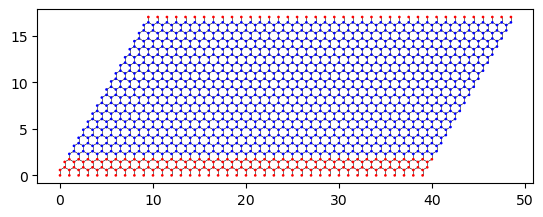

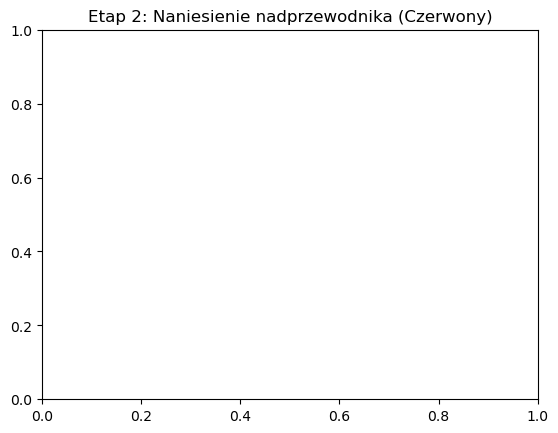

In [8]:
# Modyfikujemy tylko wybrane węzły (j=0 i j=19)
for i in range(40):
    sys[a(i, 0)] = sys[b(i, 0)] = 0.1 * s_z + 0.5 * s_x
    sys[a(i, 19)] = sys[b(i, 19)] = 0.1 * s_z + 0.5 * s_x

# Kolorujemy, żeby sprawdzić czy dobrze nałożyliśmy MoRe
def color_rule(site):
    x, y = site.pos
    return 'red' if (y < 2 or y > 17) else 'blue'

kwant.plot(sys, site_color=color_rule)
plt.title("Etap 2: Naniesienie nadprzewodnika (Czerwony)")
plt.show()

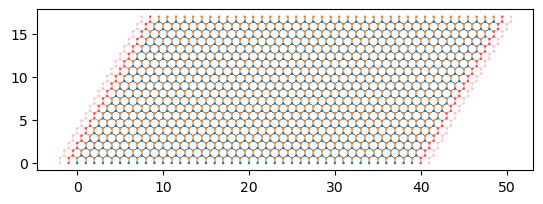

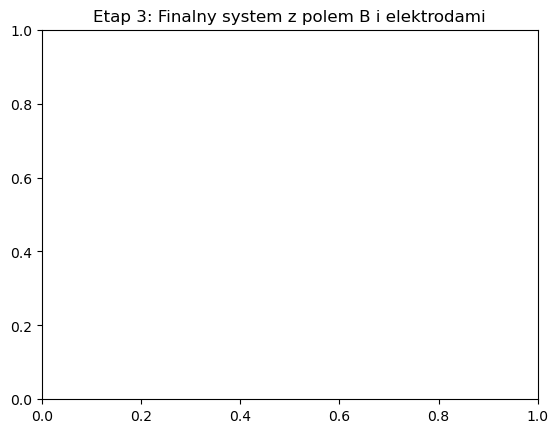

In [9]:
# 1. Nadpisujemy przeskoki funkcją z fazą Peierlsa (B=0.1)
def hopping_B(site1, site2):
    x1, y1 = site1.pos
    x2, y2 = site2.pos
    phi = np.exp(-1j * 0.1 * 0.5 * (x1 + x2) * (y1 - y2))
    return -1 * np.array([[phi, 0], [0, np.conj(phi)]])

sys[lat.neighbors()] = hopping_B

# 2. Dodanie elektrod (Leady)
sym = kwant.TranslationalSymmetry([-lat.prim_vecs[0][0], 0])
lead = kwant.Builder(sym, conservation_law=s_z)
lead[(a(0, j) for j in range(20))] = 0 * s_z
lead[(b(0, j) for j in range(20))] = 0 * s_z
lead[lat.neighbors()] = -1 * s_z

sys.attach_lead(lead)
sys.attach_lead(lead.reversed())

kwant.plot(sys)
plt.title("Etap 3: Finalny system z polem B i elektrodami")
plt.show()fsys = sys.finalized()
energies = np.linspace(0.01, 0.6, 50)
t_ee, r_he = [], []

for en in energies:
    s = kwant.smatrix(fsys, en)
    t_ee.append(s.transmission((1, 1), (0, 1))) 
    r_he.append(s.transmission((0, 0), (0, 1)))

plt.plot(energies, t_ee, label="e->e (Schody Halla)")
plt.plot(energies, r_he, label="e->h (Odbicie Andreeva)")
plt.legend()
plt.title("Wynik końcowy: Transport w hybrydzie")
plt.show()

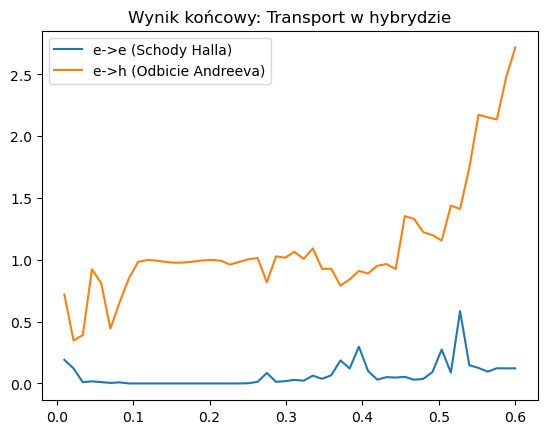

In [10]:
fsys = sys.finalized()
energies = np.linspace(0.01, 0.6, 50)
t_ee, r_he = [], []

for en in energies:
    s = kwant.smatrix(fsys, en)
    t_ee.append(s.transmission((1, 1), (0, 1))) 
    r_he.append(s.transmission((0, 0), (0, 1)))

plt.plot(energies, t_ee, label="e->e (Schody Halla)")
plt.plot(energies, r_he, label="e->h (Odbicie Andreeva)")
plt.legend()
plt.title("Wynik końcowy: Transport w hybrydzie")
plt.show()